In [35]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from rdflib import Graph


GRAPH_PATH = "../rdf_output/leipzig_housing_graph.ttl"

affordability = pd.read_csv("../data_processed/affordability_observations.csv")
housing_stock = pd.read_csv("../data_processed/housing_stock_observations.csv")
population = pd.read_csv("../data_raw/population/population_projection_leipzig.csv")

print("Affordability observations:", len(affordability))
print("Housing stock observations:", len(housing_stock))
print("Population observations:", len(population))

Affordability observations: 126
Housing stock observations: 315
Population observations: 10


In [36]:
affordability.head()

,observation_id,district_id,group_id,income_scenario_id,year,offer_rent_per_sqm,flat_size_sqm,utilities_eur,warm_rent_eur,monthly_income_eur,housing_stress_score,affordability_status,rent_source_id,income_source_id
0,affordability_althen_kleinpoesna_students_bafo...,althen_kleinpoesna,students,bafog_only,2026,8.94,30,120,388.2,992,0.391,critical,wohnungsboerse_2026,bafoeg_2024
1,affordability_althen_kleinpoesna_students_bafo...,althen_kleinpoesna,students,bafog_plus_minijob,2026,8.94,30,120,388.2,1595,0.243,affordable,wohnungsboerse_2026,bafoeg_2024_minijob_2026
2,affordability_altlindenau_students_bafog_only_...,altlindenau,students,bafog_only,2026,10.29,30,120,428.7,992,0.432,critical,wohnungsboerse_2026,bafoeg_2024
3,affordability_altlindenau_students_bafog_plus_...,altlindenau,students,bafog_plus_minijob,2026,10.29,30,120,428.7,1595,0.269,affordable,wohnungsboerse_2026,bafoeg_2024_minijob_2026
4,affordability_anger_crottendorf_students_bafog...,anger_crottendorf,students,bafog_only,2026,9.78,30,120,413.4,992,0.417,critical,wohnungsboerse_2026,bafoeg_2024


In [37]:
housing_stock.head()

,district_id,district_name,year,housing_units,source_id
0,zentrum,Zentrum,2020,2217,leipzig_housing_stock
1,zentrum_ost,Zentrum-Ost,2020,4007,leipzig_housing_stock
2,zentrum_suedost,Zentrum-Südost,2020,7549,leipzig_housing_stock
3,zentrum_sued,Zentrum-Süd,2020,8483,leipzig_housing_stock
4,zentrum_west,Zentrum-West,2020,6521,leipzig_housing_stock


In [38]:
population.head()

,year,variant,population
0,2018,variant_1,587857
1,2020,variant_1,604000
2,2025,variant_1,637590
3,2030,variant_1,663310
4,2035,variant_1,681140


In [40]:
g = Graph()
g.parse(GRAPH_PATH, format="turtle")

print("Triples:", len(g))

Triples: 444031


In [41]:
PREFIXES = """
PREFIX lh: <https://example.org/leipzig-housing/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
"""

In [42]:
query_affordability = PREFIXES + """
SELECT ?districtLabel ?stressBase ?statusBase ?stressWithMinijob ?statusWithMinijob
WHERE {
    ?baseObs a lh:AffordabilityObservation ;
         lh:forDistrict ?district ;
         lh:forGroup <https://example.org/leipzig-housing/group/students> ;
         lh:forIncomeScenario <https://example.org/leipzig-housing/income_scenario/bafog_only> ;
         lh:hasHousingStressScore ?stressBase ;
         lh:hasAffordabilityStatus ?statusBase .

    ?minijobObs a lh:AffordabilityObservation ;
         lh:forDistrict ?district ;
         lh:forGroup <https://example.org/leipzig-housing/group/students> ;
         lh:forIncomeScenario <https://example.org/leipzig-housing/income_scenario/bafog_plus_minijob> ;
         lh:hasHousingStressScore ?stressWithMinijob ;
         lh:hasAffordabilityStatus ?statusWithMinijob .

    ?district rdfs:label ?districtLabel .

    FILTER(LANG(?districtLabel) = "de")
}
ORDER BY DESC(?stressBase)
LIMIT 15
"""

In [43]:
results = []

for row in g.query(query_affordability):
    results.append({
        "district": str(row.districtLabel),
        "stress_bafog": float(row.stressBase),
        "status_bafog": str(row.statusBase),
        "stress_minijob": float(row.stressWithMinijob),
        "status_minijob": str(row.statusWithMinijob),
    })

affordability_results = pd.DataFrame(results)

affordability_results

,district,stress_bafog,status_bafog,stress_minijob,status_minijob
0,Zentrum-Ost,0.517,not_affordable,0.322,critical
1,Zentrum-Südost,0.507,not_affordable,0.315,critical
2,Zentrum-Nord,0.499,not_affordable,0.310,critical
3,Zentrum-West,0.478,not_affordable,0.297,affordable
4,Zentrum-Süd,0.477,not_affordable,0.297,affordable
5,Zentrum-Nordwest,0.473,not_affordable,0.294,affordable
6,Neulindenau,0.467,not_affordable,0.290,affordable
7,Zentrum,0.467,not_affordable,0.290,affordable
8,Hartmannsdorf-Knautnaundorf,0.461,not_affordable,0.287,affordable
9,Eutritzsch,0.453,not_affordable,0.282,affordable


In [44]:
query_housing_stock = PREFIXES + """
SELECT ?districtLabel ?housingUnits ?stress ?status
WHERE {
    ?stockObs a lh:HousingStockObservation ;
         lh:forDistrict ?district ;
         lh:inYear 2024 ;
         lh:hasHousingUnits ?housingUnits .

    ?affObs a lh:AffordabilityObservation ;
         lh:forDistrict ?district ;
         lh:forGroup <https://example.org/leipzig-housing/group/students> ;
         lh:forIncomeScenario <https://example.org/leipzig-housing/income_scenario/bafog_only> ;
         lh:hasHousingStressScore ?stress ;
         lh:hasAffordabilityStatus ?status .

    ?district rdfs:label ?districtLabel .

    FILTER(LANG(?districtLabel) = "de")
}
ORDER BY DESC(?housingUnits)
LIMIT 15
"""

In [45]:
housing_results = []

for row in g.query(query_housing_stock):
    housing_results.append({
        "district": str(row.districtLabel),
        "housing_units": int(row.housingUnits),
        "stress_score": float(row.stress),
        "status": str(row.status),
    })

housing_results_df = pd.DataFrame(housing_results)

housing_results_df

,district,housing_units,stress_score,status
0,Südvorstadt,14447,0.442,critical
1,Reudnitz-Thonberg,13324,0.448,critical
2,Connewitz,11680,0.442,critical
3,Gohlis-Süd,11097,0.446,critical
4,Altlindenau,10861,0.432,critical
5,Gohlis-Mitte,10048,0.436,critical
6,Stötteritz,9922,0.449,critical
7,Möckern,9799,0.442,critical
8,Plagwitz,9026,0.445,critical
9,Zentrum-Süd,8887,0.477,not_affordable


In [46]:
query_population = PREFIXES + """
SELECT ?year ?variantLabel ?population
WHERE {
    ?obs a lh:PopulationObservation ;
         lh:inYear ?year ;
         lh:hasPopulation ?population ;
         lh:hasVariant ?variant .

    ?variant rdfs:label ?variantLabel .
}
ORDER BY ?year ?variantLabel
"""

In [47]:
population_results = []

for row in g.query(query_population):
    population_results.append({
        "year": int(row.year),
        "variant": str(row.variantLabel),
        "population": int(row.population),
    })

population_results_df = pd.DataFrame(population_results)

population_results_df

,year,variant,population
0,2018,Lower population projection variant,587857
1,2018,Upper population projection variant,587857
2,2020,Lower population projection variant,601980
3,2020,Upper population projection variant,604000
4,2025,Lower population projection variant,628100
5,2025,Upper population projection variant,637590
6,2030,Lower population projection variant,643460
7,2030,Upper population projection variant,663310
8,2035,Lower population projection variant,651670
9,2035,Upper population projection variant,681140


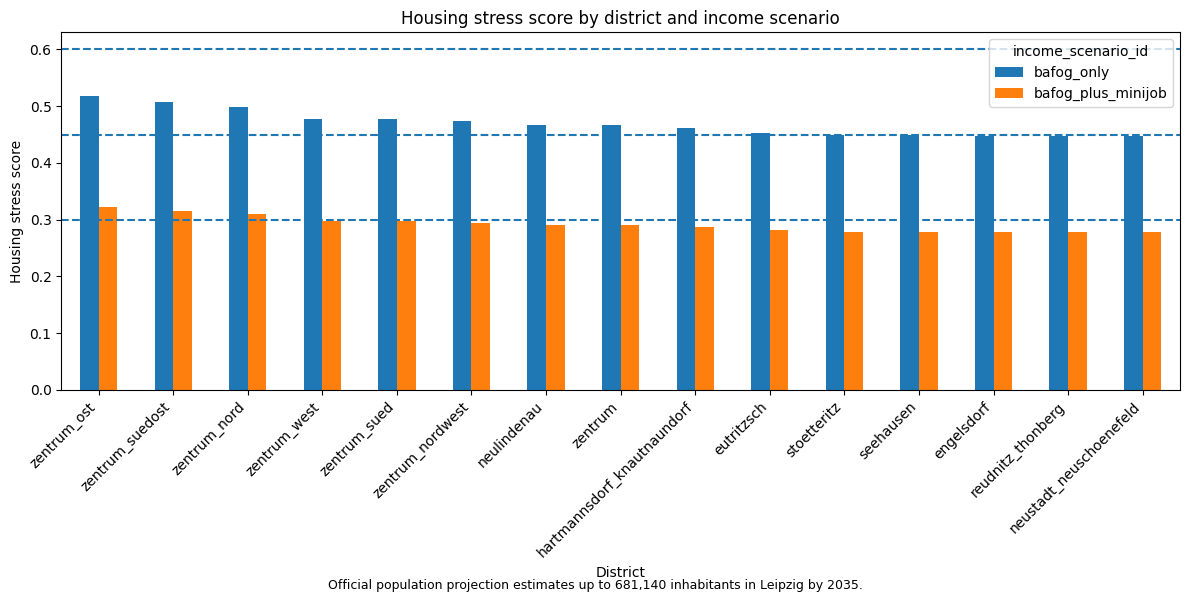

In [48]:
plot_data = affordability.pivot(
    index="district_id",
    columns="income_scenario_id",
    values="housing_stress_score",
)

plot_data = plot_data.sort_values(
    "bafog_only",
    ascending=False,
).head(15)

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6),
)

ax.axhline(0.30, linestyle="--")
ax.axhline(0.45, linestyle="--")
ax.axhline(0.60, linestyle="--")

ax.set_title(
    "Housing stress score by district and income scenario"
)

ax.set_ylabel("Housing stress score")
ax.set_xlabel("District")

plt.figtext(
    0.5,
    0.01,
    "Official population projection estimates up to 681,140 inhabitants in Leipzig by 2035.",
    ha="center",
    fontsize=9,
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

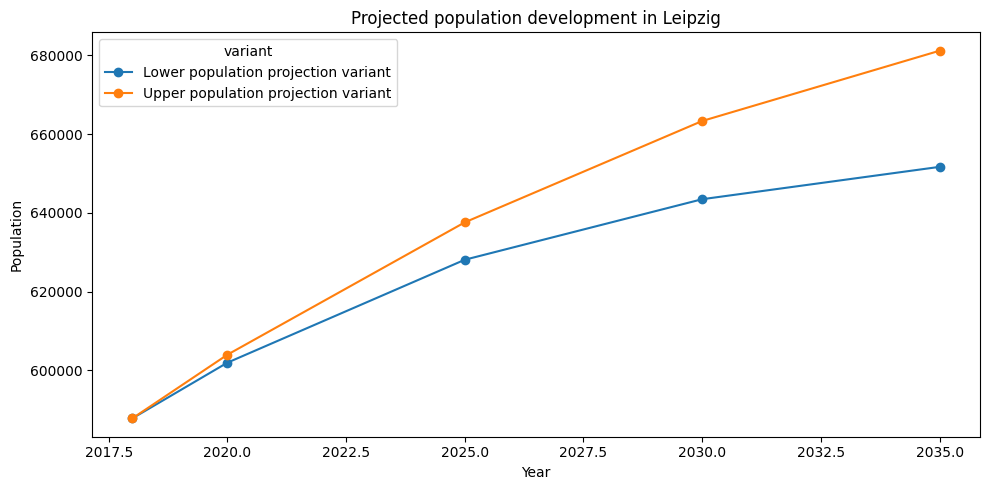

In [49]:
pivot_population = population_results_df.pivot(
    index="year",
    columns="variant",
    values="population",
)

ax = pivot_population.plot(
    figsize=(10, 5),
    marker="o",
)

ax.set_title("Projected population development in Leipzig")
ax.set_ylabel("Population")
ax.set_xlabel("Year")

plt.tight_layout()
plt.show()